# Notebook 03 — Modelos Baseline (Experimentos 1 y 2)

## Estrategia de modelado

Construimos primero los modelos **sin sentiment** para establecer un baseline sólido. Esto nos permite responder: ¿cuánto aporta el sentiment por encima de lo que ya capturan los indicadores técnicos y macro?

Los dos experimentos de este notebook son:

| Experimento | Modelo              | Features                    |
|-------------|---------------------|-----------------------------|
| 1           | Logistic Regression | Técnicas (6) + Macro (5) = 11 features |
| 2           | XGBoost             | Técnicas (6) + Macro (5) = 11 features |

**¿Por qué empezar con Logistic Regression?** LR es el modelo más simple interpretable. Si XGBoost no supera significativamente a LR, no vale la pena la complejidad adicional. También sirve para detectar si hay data leakage — un baseline con performance demasiado alta es sospechoso.

**Métricas principales**: AUC-ROC (métrica principal, insensible al desbalance), F1-score, Accuracy, matriz de confusión.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import models, utils

utils.set_plot_style()

PROCESSED_DIR = "../data/processed"
MODELS_DIR    = "../models"

# Columnas de features para este experimento (sin sentiment)
FEATURE_COLS = [
    "RSI_14", "MACD", "BB_position", "return_1d", "return_5d", "volume_change",  # técnicas
    "vix", "t10y2y", "fedfunds", "cpi", "unrate"                                  # macro
]

# Cargar features procesadas
df = pd.read_csv(f"{PROCESSED_DIR}/sp500_features.csv", index_col=0, parse_dates=True)
df = df.dropna(subset=FEATURE_COLS)  # eliminar primeras filas con NaN en indicadores técnicos
print(f"Dataset: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")

Dataset: (4491, 17) | 2008-02-13 → 2025-12-18


c:\Users\pepob\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Split temporal

El split temporal es la decisión de diseño más importante del proyecto. **No usamos shuffle** porque el S&P 500 es una serie temporal — mezclar fechas causaría que el modelo aprenda del futuro (data leakage).

El split refleja un escenario realista: entrenas con datos históricos y predecís el futuro.

| Conjunto | Período        | 
|----------|----------------|
| Train    | 2008–2024 (12 años)  |
| Val      | 2024 (1 año)         |
| Test     | 2025 (1 años)        |


In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = models.temporal_split(
    df, features=FEATURE_COLS, target="target"
)

print(f"\nBalance de clases:")
for nombre, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {nombre}: {y.mean()*100:.1f}% positivos")

[models] Split temporal:
  train: 3,997 muestras (2008-02-13 → 2023-12-29)
  val:   252 muestras (2024-01-02 → 2024-12-31)
  test:  242 muestras (2025-01-02 → 2025-12-18)

Balance de clases:
  Train: 54.1% positivos
  Val: 56.7% positivos
  Test: 58.3% positivos


## Escalado de features

El StandardScaler transforma cada feature para tener media 0 y desviación estándar 1. Esto es necesario para Logistic Regression y MLP, que son sensibles a la escala de los inputs (el gradiente descende más eficientemente cuando las features están en la misma escala).

**Regla clave**: el scaler se **fitea solo sobre X_train** y se aplica a val y test. Si fitearamos sobre todo el dataset, estaríamos filtrando información del futuro hacia el pasado (data leakage estadístico).

XGBoost es insensible a la escala (usa splits binarios), pero escalamos igualmente para consistencia y para poder reutilizar el mismo pipeline en todos los experimentos.

In [3]:
X_train_s, X_val_s, X_test_s, scaler = models.scale_features(X_train, X_val, X_test)

print(f"Medias en train (post-scaling): {X_train_s.mean(axis=0).round(4)}")
print(f"Std en train (post-scaling):    {X_train_s.std(axis=0).round(4)}")

Medias en train (post-scaling): [-0. -0.  0. -0. -0.  0. -0. -0.  0.  0. -0.]
Std en train (post-scaling):    [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Experimento 1: Logistic Regression

Logistic Regression es el modelo más simple que podemos usar para clasificación binaria. Asume una relación **lineal** entre las features y el log-odds del target, lo que lo hace:
- Fácil de interpretar (los coeficientes tienen significado directo)
- Un buen detector de data leakage (si el AUC es > 0.65, hay que investigar)
- Un baseline que modelos más complejos deberían superar para justificar su complejidad

Usamos `class_weight='balanced'` para compensar el leve desbalance de clases (el modelo pondera más los errores en la clase minoritaria).

In [4]:
lr = models.train_logistic_regression(X_train_s, y_train)

metricas_lr = {}
for nombre, X, y in [("train", X_train_s, y_train), ("val", X_val_s, y_val), ("test", X_test_s, y_test)]:
    metricas_lr[nombre] = models.evaluate_model(lr, X, y, nombre)

# Guardar modelo
models.save_model(lr, scaler, "logistic_regression", MODELS_DIR)


── TRAIN ──
  accuracy    : 0.5211
  f1          : 0.5216
  roc_auc     : 0.5382
  precision   : 0.527
  recall      : 0.5211

── VAL ──
  accuracy    : 0.4405
  f1          : 0.3893
  roc_auc     : 0.5351
  precision   : 0.4771
  recall      : 0.4405

── TEST ──
  accuracy    : 0.4752
  f1          : 0.4228
  roc_auc     : 0.5178
  precision   : 0.5653
  recall      : 0.4752
[models] logistic_regression guardado en ../models/


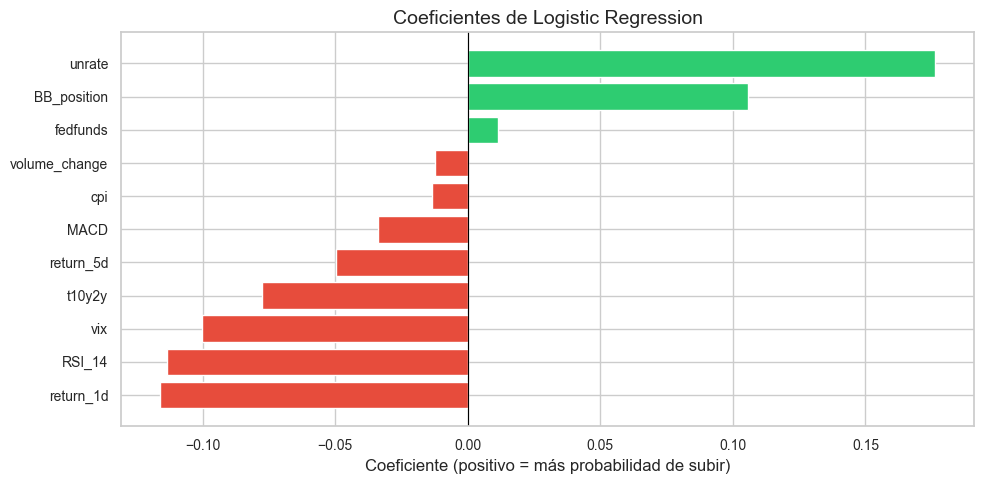

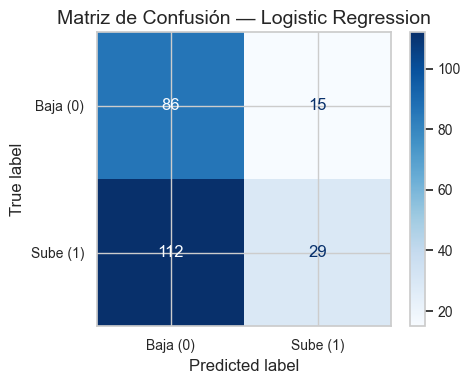

In [5]:
# Coeficientes del modelo — interpretabilidad de LR
coefs = pd.Series(lr.coef_[0], index=FEATURE_COLS).sort_values()

plt.figure(figsize=(10, 5))
colores = ["#e74c3c" if v < 0 else "#2ecc71" for v in coefs.values]
plt.barh(coefs.index, coefs.values, color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coeficientes de Logistic Regression")
plt.xlabel("Coeficiente (positivo = más probabilidad de subir)")
plt.tight_layout()
plt.show()

utils.plot_confusion_matrix(y_test, lr.predict(X_test_s), "Logistic Regression")

## Experimento 2: XGBoost

XGBoost es un ensemble de árboles de decisión entrenados de forma secuencial (gradient boosting). Captura relaciones **no-lineales** e **interacciones** entre features que Logistic Regression no puede modelar.

Ventajas clave para este problema:
- `scale_pos_weight`: compensa el desbalance de clases directamente en la función de pérdida
- **Early stopping**: para el entrenamiento cuando el AUC en validación no mejora en 50 rondas, previniendo overfitting
- Robusto a outliers y features con distintas escalas
- Rápido: corre en segundos en CPU

In [6]:
xgb = models.train_xgboost(X_train_s, y_train, X_val_s, y_val)

metricas_xgb = {}
for nombre, X, y in [("train", X_train_s, y_train), ("val", X_val_s, y_val), ("test", X_test_s, y_test)]:
    metricas_xgb[nombre] = models.evaluate_model(xgb, X, y, nombre)

models.save_model(xgb, scaler, "xgboost_baseline", MODELS_DIR)

[models] XGBoost entrenado. Mejor ronda: 20

── TRAIN ──
  accuracy    : 0.617
  f1          : 0.6154
  roc_auc     : 0.6736
  precision   : 0.6153
  recall      : 0.617

── VAL ──
  accuracy    : 0.5516
  f1          : 0.5532
  roc_auc     : 0.5416
  precision   : 0.5657
  recall      : 0.5516

── TEST ──
  accuracy    : 0.5207
  f1          : 0.5223
  roc_auc     : 0.5317
  precision   : 0.5449
  recall      : 0.5207
[models] xgboost_baseline guardado en ../models/


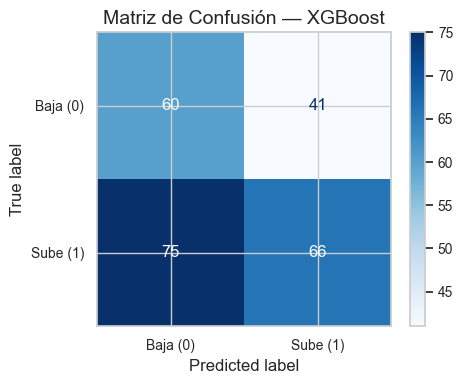

In [7]:
utils.plot_confusion_matrix(y_test, xgb.predict(X_test_s), "XGBoost")

## Comparación de modelos y análisis de errores

Comparamos Logistic Regression y XGBoost en los tres conjuntos. Prestamos atención a:
- **Gap train-val**: si el train AUC es mucho mayor que el val AUC → overfitting
- **Gap val-test**: si cae mucho en test → el modelo no generalizó bien al año 2025
- **AUC base**: en mercados eficientes, esperamos AUC entre 0.51 y 0.58 en test

El **análisis de errores** busca patrones en las predicciones incorrectas: ¿el modelo falla más en días de alta volatilidad? ¿En ciertos meses de 2025?

In [8]:
# Tabla comparativa
tabla = pd.DataFrame([
    {"Modelo": "Logistic Regression", "Split": s, **{k: v for k, v in m.items() if k not in ["split"]}}
    for s, m in metricas_lr.items()
] + [
    {"Modelo": "XGBoost", "Split": s, **{k: v for k, v in m.items() if k not in ["split"]}}
    for s, m in metricas_xgb.items()
])

print("Tabla de métricas — Experimentos 1 y 2:")
display(tabla.set_index(["Modelo", "Split"]))

Tabla de métricas — Experimentos 1 y 2:


accuracy      f1  roc_auc  precision  recall
Modelo              Split                                              
Logistic Regression train    0.5211  0.5216   0.5382     0.5270  0.5211
                    val      0.4405  0.3893   0.5351     0.4771  0.4405
                    test     0.4752  0.4228   0.5178     0.5653  0.4752
XGBoost             train    0.6170  0.6154   0.6736     0.6153  0.6170
                    val      0.5516  0.5532   0.5416     0.5657  0.5516
                    test     0.5207  0.5223   0.5317     0.5449  0.5207

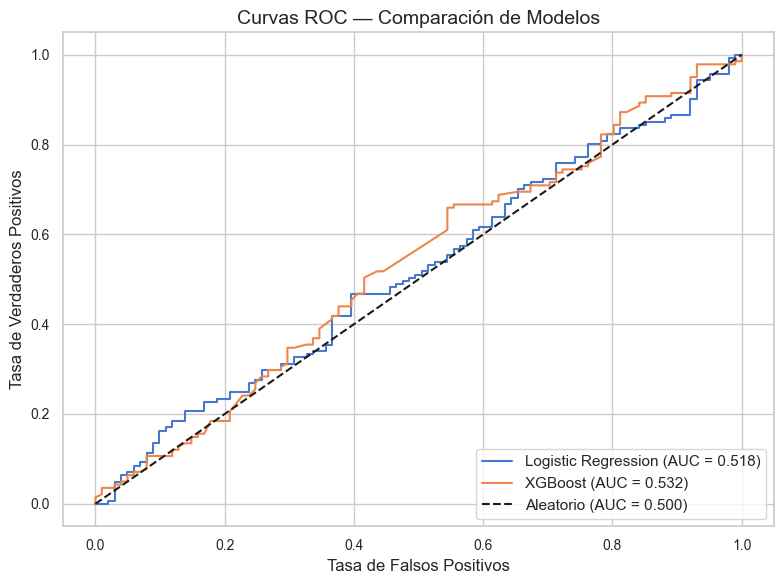

In [9]:
# Curvas ROC comparativas
utils.plot_roc_curves(
    {"Logistic Regression": lr, "XGBoost": xgb},
    X_test_s, y_test
)

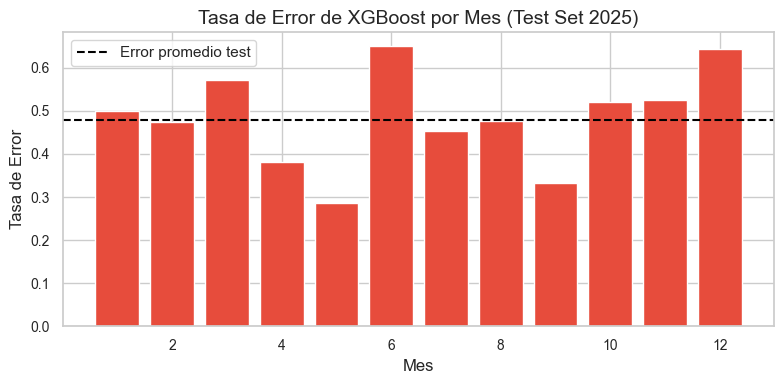

In [10]:
# Análisis de errores: ¿en qué meses falla más el XGBoost en 2025?
test_df = df[df.index.year >= 2025].copy()
test_df["pred_xgb"]   = xgb.predict(X_test_s)
test_df["error_xgb"]  = (test_df["pred_xgb"] != test_df["target"]).astype(int)

error_por_mes = test_df.groupby(test_df.index.month)["error_xgb"].mean()

plt.figure(figsize=(8, 4))
plt.bar(error_por_mes.index, error_por_mes.values, color="#e74c3c")
plt.axhline(1 - metricas_xgb["test"]["accuracy"], color="black",
            linestyle="--", label="Error promedio test")
plt.title("Tasa de Error de XGBoost por Mes (Test Set 2025)")
plt.xlabel("Mes")
plt.ylabel("Tasa de Error")
plt.legend()
plt.tight_layout()
plt.show()